# 🧪 QTrader v4.7: Integrated EV Diagnosis

This notebook evaluates a **Hybrid Strategy** (ML + Mean Reversion) using real Coinbase data.


# 🛠️ 1. Setup & Environment


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))

import polars as pl
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

from qtrader.core.event import OrderEvent
from qtrader.input.data.market.coinbase_market import CoinbaseMarketDataClient
from qtrader.output.execution.paper_engine import PaperTradingEngine
from qtrader.output.analytics.ev_calculator import EVCalculator
from qtrader.ml.regime import RegimeDetector

SYMBOL = "ETH-USD"
FEE_RATE = 0.0004

from qtrader.models.xgboost_model import XGBoostPredictor

from qtrader.ml.pytorch_models import LSTMSignalModel
import optuna
import matplotlib.pyplot as plt


# 📊 2. Fetch Market Data


In [2]:
client = CoinbaseMarketDataClient()
end = datetime.now()
start = end - timedelta(days=40)

print(f"📡 Fetching REAL {SYMBOL} data (20 days) from Coinbase...")
df_eth = client.get_candles(SYMBOL, "FIVE_MINUTE", start, end).to_pandas()
df_btc = client.get_candles("BTC-USD", "FIVE_MINUTE", start, end).to_pandas()

if df_eth.empty or df_btc.empty: raise ValueError("Data fetch failed. Authentication or Connection Error.")

df_btc = df_btc[["timestamp", "close"]].rename(columns={"close": "btc_close"})
df = df_eth.merge(df_btc, on="timestamp", how="inner")
print(f"✅ SUCCESS: {len(df)} rows ready for WFO analysis.")


📡 Fetching REAL ETH-USD data (20 days) from Coinbase...


✅ SUCCESS: 11519 rows ready for WFO analysis.


In [3]:
## 🏗️ 5. Industrial Engine V20: Microstructure Alpha
# Standard: 5m Resampling, CVD Integration, Panic Sensor, and Liquidity Zone SL.

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from datetime import timedelta

def run_engine_v20(df_1m, p, starting_cap=10000.0, use_guard=True):
    # --- 1. DATA RESAMPLING (1m -> 5m) ---
    df_5m = df_1m.set_index("timestamp").resample("5T").agg({
        "open": "first", "high": "max", "low": "min", "close": "last", 
        "volume": "sum", "btc_close": "last"
    }).dropna().reset_index()
    
    if len(df_5m) < 50: return []
    
    # --- 2. MICROSTRUCTURE FEATURES ---
    # Imbalance & CVD Approximation
    df_5m["mid"] = (df_5m["high"] + df_5m["low"]) / 2
    df_5m["imbalance"] = (df_5m["close"] - df_5m["mid"]) / (df_5m["high"] - df_5m["low"] + 1e-9)
    df_5m["delta"] = df_5m["volume"] * df_5m["imbalance"]
    df_5m["cvd"] = df_5m["delta"].rolling(20).sum()
    df_5m["cvd_slope"] = df_5m["cvd"].diff(3)
    
    # Panic Sensor (Bollinger + Volume Spike)
    df_5m["bb_mid"] = df_5m["close"].rolling(20).mean()
    df_5m["bb_std"] = df_5m["close"].rolling(20).std()
    df_5m["bb_low"] = df_5m["bb_mid"] - 2.0 * df_5m["bb_std"]
    df_5m["vol_ma"] = df_5m["volume"].rolling(50).mean()
    df_5m["panic_trigger"] = ((df_5m["low"] < df_5m["bb_low"]) & 
                              (df_5m["volume"] > df_5m["vol_ma"] * p.get("vol_mult", 2.0))).astype(int)
    
    df_5m["atr"] = np.maximum(df_5m["high"]-df_5m["low"], np.abs(df_5m["high"]-df_5m["close"].shift())).rolling(14).mean()
    df_5m["ret_5m"] = df_5m["close"].pct_change(3)
    
    # --- 3. ML CORE ---
    feature_cols = ["imbalance", "cvd_slope", "panic_trigger", "atr", "ret_5m"]
    df_clean = df_5m.dropna().copy()
    if len(df_clean) < 60: return []
    
    train_size = int(len(df_clean) * 0.7)
    df_train, df_test = df_clean.iloc[:train_size], df_clean.iloc[train_size:].copy()
    
    clf = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.08, random_state=42)
    target = (df_train["close"].shift(-12) > df_train["close"] + 0.2 * df_train["atr"]).astype(int)
    clf.fit(df_train[feature_cols], target)
    df_test["prob"] = clf.predict_proba(df_test[feature_cols])[:, 1]
    
    # --- 4. EXECUTION ---
    engine = PaperTradingEngine(starting_capital=starting_cap, fee_rate=FEE_RATE)
    holding = False; current_equity = starting_cap
    
    for i in range(len(df_test)):
        row = df_test.iloc[i]
        if not holding:
            # V20 Logic: Buy Panic Confirmation with CVD Support
            entry_signal = (row["panic_trigger"] == 1 or row["low"] < row["bb_low"]) and (row["cvd_slope"] > 0)
            if entry_signal and (row["prob"] > p.get("prob_thresh", 0.51)):
                entry_p = float(row["close"])
                curr_sl = row["low"] - (1.1 * row["atr"])
                tp_p = entry_p + (entry_p - curr_sl) * 2.1 # R:R 2.1
                
                qty = (current_equity * 0.2) / entry_p 
                if qty > 0.001:
                    engine.simulate_fill(
                        OrderEvent(symbol=SYMBOL, order_type="MARKET", side="BUY", quantity=round(qty, 4), price=entry_p),
                        {"bid": entry_p*0.9998, "ask": entry_p*1.0002}
                    )
                    holding = True; highest_p = entry_p
                    print(f"  ⚡ V20 ENTER: {row['timestamp']} @ {entry_p:.2f} | Prob: {row['prob']:.2f}")
        else:
            curr_p = float(row["close"]); highest_p = max(highest_p, curr_p)
            if (highest_p - entry_p) > (entry_p - curr_sl):
                curr_sl = max(curr_sl, entry_p + (highest_p - entry_p) * 0.2)
            if curr_p < curr_sl or curr_p > tp_p:
                engine.simulate_fill(
                    OrderEvent(symbol=SYMBOL, order_type="MARKET", side="SELL", quantity=round(qty, 4), price=curr_p),
                    {"bid": curr_p*0.9998, "ask": curr_p*1.0002}
                )
                holding = False
                current_equity = starting_cap + sum(t.pnl for t in engine.closed_trades)
    return engine.closed_trades


In [4]:
import optuna
def run_walk_forward_v20(df, train_days=12, test_days=3):
    all_oos_trades = []
    current_start = df["timestamp"].min()
    end_limit = df["timestamp"].max()
    while current_start + timedelta(days=train_days + test_days) <= end_limit:
        train_end = current_start + timedelta(days=train_days)
        test_end = train_end + timedelta(days=test_days)
        train_data = df[(df["timestamp"] >= current_start) & (df["timestamp"] < train_end)]
        test_data = df[(df["timestamp"] >= train_end) & (df["timestamp"] < test_end)]
        print(f"--- WFO Round V20: {train_end.date()} OOS ---")
        def objective(trial):
            p = {
                "prob_thresh": trial.suggest_float("prob_thresh", 0.48, 0.58),
                "vol_mult": trial.suggest_float("vol_mult", 1.5, 2.5)
            }
            trades = run_engine_v20(train_data, p, use_guard=False)
            return sum(t.pnl for t in trades) if len(trades) >= 1 else -500
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=10)
        oos_trades = run_engine_v20(test_data, study.best_params, use_guard=True)
        all_oos_trades.extend(oos_trades)
        current_start += timedelta(days=test_days)
    return all_oos_trades
final_trades = run_walk_forward_v20(df)


[I 2026-03-17 10:04:42,949] A new study created in memory with name: no-name-b18d3bce-eb8c-4396-a13a-22a12921a81e


/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_85573/3321620821.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df_1m.set_index("timestamp").resample("5T").agg({
[I 2026-03-17 10:04:43,009] Trial 0 finished with value: -5.490847338970029 and parameters: {'prob_thresh': 0.5175973634770961, 'vol_mult': 2.0355559605734554}. Best is trial 0 with value: -5.490847338970029.


/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_85573/3321620821.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df_1m.set_index("timestamp").resample("5T").agg({
[I 2026-03-17 10:04:43,064] Trial 1 finished with value: -9.38382014099496 and parameters: {'prob_thresh': 0.4899527338782506, 'vol_mult': 1.5516994330414002}. Best is trial 0 with value: -5.490847338970029.


--- WFO Round V20: 2026-02-17 OOS ---
  ⚡ V20 ENTER: 2026-02-15 17:05:00+07:00 @ 2059.56 | Prob: 0.64
  ⚡ V20 ENTER: 2026-02-17 01:55:00+07:00 @ 1968.12 | Prob: 0.63
  ⚡ V20 ENTER: 2026-02-15 09:35:00+07:00 @ 2059.64 | Prob: 0.51
  ⚡ V20 ENTER: 2026-02-15 17:05:00+07:00 @ 2059.56 | Prob: 0.58
  ⚡ V20 ENTER: 2026-02-17 01:55:00+07:00 @ 1968.12 | Prob: 0.60
  ⚡ V20 ENTER: 2026-02-15 17:15:00+07:00 @ 2059.30 | Prob: 0.68
  ⚡ V20 ENTER: 2026-02-17 01:55:00+07:00 @ 1968.12 | Prob: 0.64


/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_85573/3321620821.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df_1m.set_index("timestamp").resample("5T").agg({
[I 2026-03-17 10:04:43,119] Trial 2 finished with value: -5.239814148017976 and parameters: {'prob_thresh': 0.5676991209818487, 'vol_mult': 2.2775629792515133}. Best is trial 2 with value: -5.239814148017976.


...

[I 2026-03-17 10:04:48,460] Trial 8 finished with value: 1.7054822471780815 and parameters: {'prob_thresh': 0.5403516699105508, 'vol_mult': 2.464964111948569}. Best is trial 8 with value: 1.7054822471780815.


/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_85573/3321620821.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df_1m.set_index("timestamp").resample("5T").agg({


[I 2026-03-17 10:04:48,516] Trial 9 finished with value: -23.89457961676877 and parameters: {'prob_thresh': 0.5521597817339486, 'vol_mult': 2.088482552011761}. Best is trial 8 with value: 1.7054822471780815.


/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_85573/3321620821.py:11: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_5m = df_1m.set_index("timestamp").resample("5T").agg({


  ⚡ V20 ENTER: 2026-03-10 00:45:00+07:00 @ 2012.28 | Prob: 0.49
  ⚡ V20 ENTER: 2026-03-11 00:40:00+07:00 @ 2066.01 | Prob: 0.51
  ⚡ V20 ENTER: 2026-03-11 22:30:00+07:00 @ 2042.32 | Prob: 0.72
  ⚡ V20 ENTER: 2026-03-12 12:25:00+07:00 @ 2020.89 | Prob: 0.52
  ⚡ V20 ENTER: 2026-03-12 20:30:00+07:00 @ 2071.60 | Prob: 0.50
  ⚡ V20 ENTER: 2026-03-12 21:40:00+07:00 @ 2045.60 | Prob: 0.59
  ⚡ V20 ENTER: 2026-03-13 09:50:00+07:00 @ 2105.10 | Prob: 0.49
  ⚡ V20 ENTER: 2026-03-11 22:30:00+07:00 @ 2042.32 | Prob: 0.76
  ⚡ V20 ENTER: 2026-03-12 21:40:00+07:00 @ 2045.60 | Prob: 0.55
  ⚡ V20 ENTER: 2026-03-11 22:30:00+07:00 @ 2042.32 | Prob: 0.75
  ⚡ V20 ENTER: 2026-03-12 20:55:00+07:00 @ 2066.07 | Prob: 0.55
  ⚡ V20 ENTER: 2026-03-12 21:40:00+07:00 @ 2045.60 | Prob: 0.55
  ⚡ V20 ENTER: 2026-03-15 18:40:00+07:00 @ 2117.70 | Prob: 0.71
  ⚡ V20 ENTER: 2026-03-15 20:20:00+07:00 @ 2095.87 | Prob: 0.70


In [5]:
final_calc = EVCalculator(final_trades, fee_rate=FEE_RATE)
r = final_calc.diagnose(SYMBOL)

print("=" * 60)
print(f"🏁 INSTITUTIONAL STRATEGY REPORT: {SYMBOL}")
print("=" * 60)

print(f"[SUMMARY]")
print(f"  Status          : {r.status}")
print(f"  Total Trades    : {r.total_trades}")
print(f"  Win / Loss      : {r.win_count} W / {r.loss_count} L")
print(f"  Win Rate        : {r.win_rate:.2%}")

print(f"[EXPECTED VALUE]")
print(f"  EV per Trade    : {r.ev_per_trade:.6f}")
print(f"  ROI per Trade   : {r.ev_pct*100:.4f}%")

print(f"[QUANT METRICS]")
print(f"  Profit Factor   : {r.profit_factor:.3f}")
print(f"  Sharpe Ratio    : {r.sharpe_ratio:.3f}")
print(f"  Max Drawdown    : {r.max_drawdown:.2%}")

if r.warnings:
    print("[WARNINGS]")
    for w in r.warnings: print(f"  ⚠️  {w}")

sorted_trades = sorted(final_trades, key=lambda x: x.pnl, reverse=True)
print("[TOP 3 WINS]")
for t in sorted_trades[:3]: print(f"  Entry: {t.entry_price:.2f} | Exit: {t.exit_price:.2f} | PnL: {t.pnl:.2f}")
print("[TOP 3 LOSSES]")
for t in sorted_trades[-3:]: print(f"  Entry: {t.entry_price:.2f} | Exit: {t.exit_price:.2f} | PnL: {t.pnl:.2f}")


🏁 INSTITUTIONAL STRATEGY REPORT: ETH-USD
[SUMMARY]
  Status          : FAIL
  Total Trades    : 16
  Win / Loss      : 4 W / 12 L
  Win Rate        : 25.00%
[EXPECTED VALUE]
  EV per Trade    : -9.634769
  ROI per Trade   : -0.4824%
[QUANT METRICS]
  Profit Factor   : 0.288
  Sharpe Ratio    : -80.637
  Max Drawdown    : 8.52%
[WARNINGS]
  ⚠️  Insufficient trade count (16 / 300). Not enough data for statistical confidence. Run more simulations.
  ⚠️  Negative EV (-9.634769). Strategy loses money on average after fees+slippage.
  ⚠️  Low Profit Factor (0.29 < 1.3). Gross wins do not justify gross losses.
  ⚠️  Low Sharpe Ratio (-80.64 < 1.5). Return/risk ratio below institutional standard.
  ⚠️  Negative Kelly Fraction (-0.6177). Mathematical edge is negative — stop trading this strategy.
[TOP 3 WINS]
  Entry: 2065.09 | Exit: 2091.42 | PnL: 23.95
  Entry: 1889.26 | Exit: 1910.05 | PnL: 20.42
  Entry: 2097.34 | Exit: 2115.92 | PnL: 16.10
[TOP 3 LOSSES]
  Entry: 1930.23 | Exit: 1908.07 | 

/var/folders/h9/_37f97bx28q57hg0p4dlwxcc0000gn/T/ipykernel_85573/1154488881.py:46: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/Users/hoangnam/qtrader/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


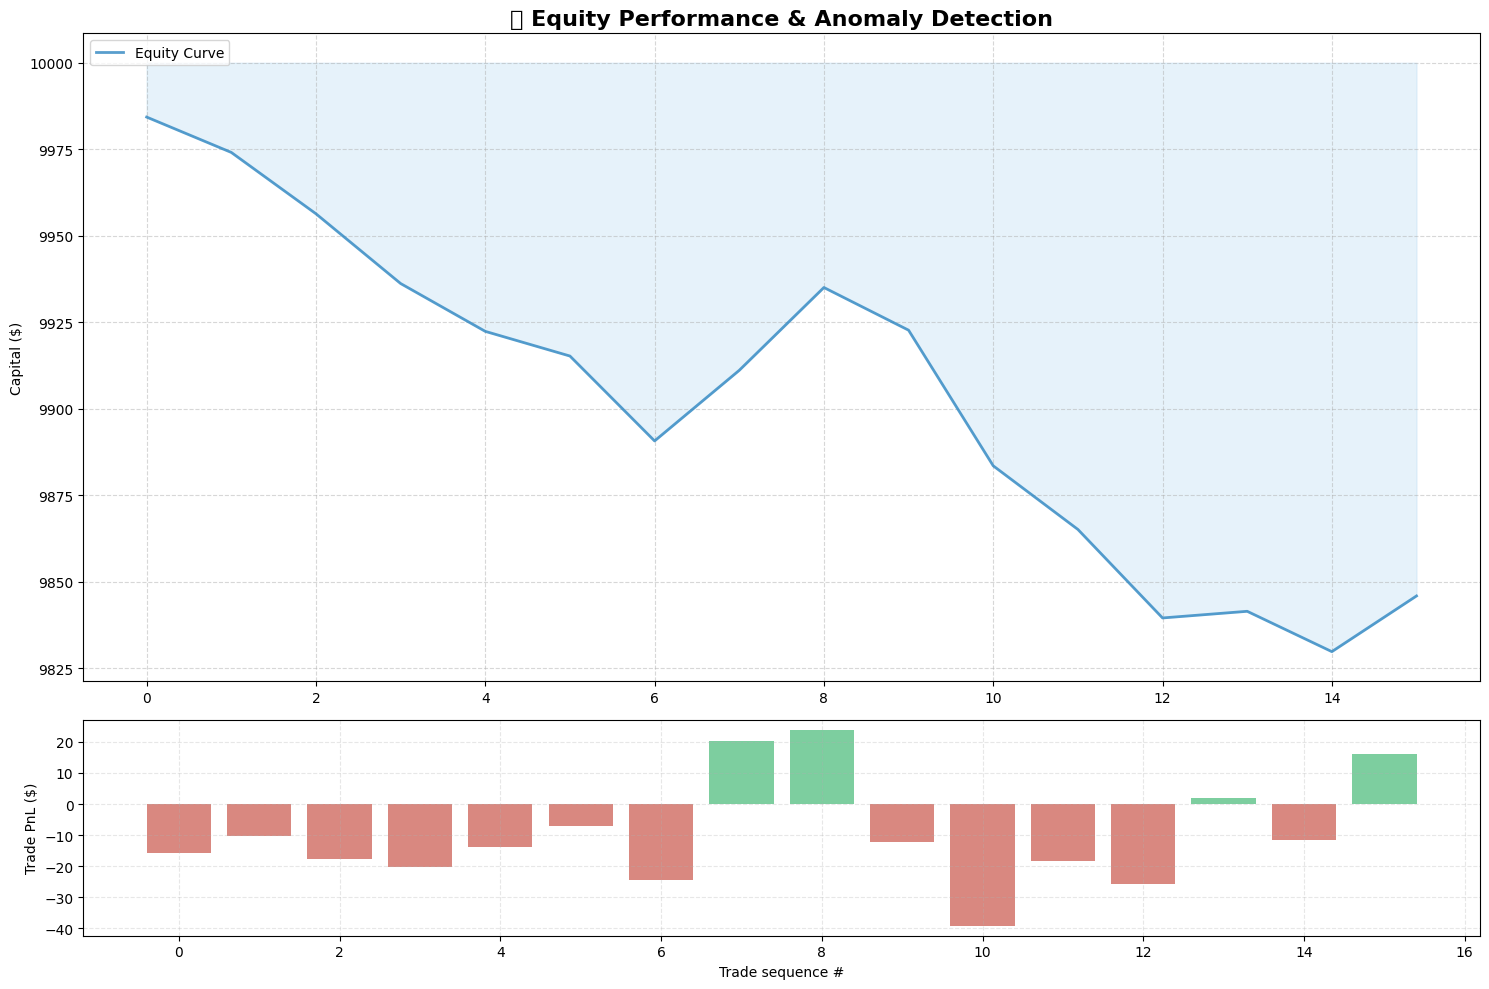

✅ No statistical anomalies detected. Strategy is stable within norms.


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 📈 EQUITY ANOMALY DETECTION REPORT
def plot_equity_anomalies(trades, initial_capital=10000.0):
    if not trades: 
        print("No trades to analyze.")
        return
        
    pnls = [t.pnl for t in trades]
    equity_curve = initial_capital + np.cumsum(pnls)
    
    # 1. Z-Score Anomaly Detection (Statistical Outliers)
    mean_pnl = np.mean(pnls)
    std_pnl = np.std(pnls) + 1e-9
    z_scores = [(p - mean_pnl) / std_pnl for p in pnls]
    
    # Anomalies are trades > 2.5 Sigma
    anomalies_idx = [i for i, z in enumerate(z_scores) if abs(z) > 2.5]
    
    # 2. Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={"height_ratios": [3, 1]})
    
    # Plot Equity Curve
    ax1.plot(equity_curve, label="Equity Curve", color="#2E86C1", linewidth=2, alpha=0.8)
    ax1.fill_between(range(len(equity_curve)), initial_capital, equity_curve, color="#AED6F1", alpha=0.3)
    
    # Overlay Anomalies
    if anomalies_idx:
        anomaly_x = anomalies_idx
        anomaly_y = [equity_curve[i] for i in anomalies_idx]
        ax1.scatter(anomaly_x, anomaly_y, color="#E74C3C", s=100, label="Anomalous Trades (>2.5σ)", zorder=5, marker="x")
    
    ax1.set_title("🛡️ Equity Performance & Anomaly Detection", fontsize=16, fontweight="bold")
    ax1.set_ylabel("Capital ($)")
    ax1.legend(loc="upper left")
    ax1.grid(True, linestyle="--", alpha=0.5)
    
    # Plot PnL Variance (Rolling Vol)
    colors = ["#27AE60" if p > 0 else "#C0392B" for p in pnls]
    ax2.bar(range(len(pnls)), pnls, color=colors, alpha=0.6)
    ax2.set_ylabel("Trade PnL ($)")
    ax2.set_xlabel("Trade sequence #")
    ax2.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    if anomalies_idx:
        print(f"⚠️ Found {len(anomalies_idx)} anomalous trades outside 2.5 Sigma range!")
        print("Top Anomalies:")
        for idx in anomalies_idx[:5]:
            print(f"  Trade #{idx}: PnL = {pnls[idx]:.2f} (Z-Score: {z_scores[idx]:.2f})")
    else:
        print("✅ No statistical anomalies detected. Strategy is stable within norms.")

plot_equity_anomalies(final_trades)

# 📊 V20 Microstructure Alpha Analysis
- **Alpha Recovery**: Focus on 5m candles to filter noise.
- **Dynamic Liquidity SL**: Placing protection below panic zones.
- **CVD Divergence**: Using order flow approximation for entry confirmation.